# **Projekt: „Optymalizacja portfela inwestycyjnego według modelu Markowitza”**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Dane wejściowe**

Na tym etapie załadowano dane historyczne dotyczące cen aktywów za wybrany okres z wykorzystaniem biblioteki yfinance. Otrzymane dane stanowią szereg czasowy cen aktywów, który jest wykorzystywany do:

*   obliczania stóp zwrotu
*   oceny ryzyka

*   budowy portfeli inwestycyjnych




In [2]:
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

tickers = ["AAPL", "MSFT", "GOOGL",  "AMZN", "NVDA", "META", "TSLA","JPM","XOM", "KO","BTC-USD","GLD"]
data = yf.download(tickers, start="2016-01-01", end="2026-01-01",progress=False)
stock_prices = data["Close"].ffill().dropna().reset_index()

stock_prices

Ticker,Date,AAPL,AMZN,BTC-USD,GLD,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,XOM
0,2016-01-04,23.730946,31.849501,433.091003,102.889999,37.660736,48.401131,30.753246,101.424088,47.874187,0.789545,14.894000,49.654381
1,2016-01-05,23.136261,31.689501,431.959991,103.180000,37.764378,48.484821,30.862047,101.930122,48.092602,0.802228,14.895333,50.077450
2,2016-01-06,22.683498,31.632500,429.105011,104.669998,37.655273,47.784889,30.695221,102.168228,47.218983,0.769056,14.602667,49.660782
3,2016-01-07,21.726149,30.396999,458.048004,106.150002,36.746296,45.852497,30.187492,97.157555,45.576572,0.738567,14.376667,48.865906
4,2016-01-08,21.841030,30.352501,453.230011,105.680000,36.245930,44.825432,30.107716,96.572159,45.716362,0.722713,14.066667,47.878712
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3645,2025-12-27,273.144409,232.520004,87802.156250,416.739990,313.289459,324.775421,69.392860,662.722595,486.599365,190.519684,475.190002,118.321342
3646,2025-12-28,273.144409,232.520004,87835.835938,416.739990,313.289459,324.775421,69.392860,662.722595,486.599365,190.519684,475.190002,118.321342
3647,2025-12-29,273.504089,232.070007,87138.140625,398.600006,313.339417,320.655182,69.680878,658.126526,485.990753,188.209808,459.640015,119.731941
3648,2025-12-30,272.824707,232.529999,88430.132812,398.890015,313.629242,320.328339,69.591492,665.380310,486.369904,187.529846,454.429993,120.188896


Do dalszych obliczeń (stóp zwrotu, ryzyka, kowariancji) wykorzystywane są wyłącznie dane liczbowe. Kolumna z datami nie bierze udziału w operacjach matematycznych, dlatego jej usunięcie upraszcza przetwarzanie danych.

In [3]:
stock_prices_drop_date = stock_prices.drop(columns=['Date'])
stock_prices_drop_date

Ticker,AAPL,AMZN,BTC-USD,GLD,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,XOM
0,23.730946,31.849501,433.091003,102.889999,37.660736,48.401131,30.753246,101.424088,47.874187,0.789545,14.894000,49.654381
1,23.136261,31.689501,431.959991,103.180000,37.764378,48.484821,30.862047,101.930122,48.092602,0.802228,14.895333,50.077450
2,22.683498,31.632500,429.105011,104.669998,37.655273,47.784889,30.695221,102.168228,47.218983,0.769056,14.602667,49.660782
3,21.726149,30.396999,458.048004,106.150002,36.746296,45.852497,30.187492,97.157555,45.576572,0.738567,14.376667,48.865906
4,21.841030,30.352501,453.230011,105.680000,36.245930,44.825432,30.107716,96.572159,45.716362,0.722713,14.066667,47.878712
...,...,...,...,...,...,...,...,...,...,...,...,...
3645,273.144409,232.520004,87802.156250,416.739990,313.289459,324.775421,69.392860,662.722595,486.599365,190.519684,475.190002,118.321342
3646,273.144409,232.520004,87835.835938,416.739990,313.289459,324.775421,69.392860,662.722595,486.599365,190.519684,475.190002,118.321342
3647,273.504089,232.070007,87138.140625,398.600006,313.339417,320.655182,69.680878,658.126526,485.990753,188.209808,459.640015,119.731941
3648,272.824707,232.529999,88430.132812,398.890015,313.629242,320.328339,69.591492,665.380310,486.369904,187.529846,454.429993,120.188896


# **Wykres cen aktywów**

Na tym etapie sporządzono wykres zmian ceny wybranego aktywa w długim okresie czasu. Wykres pozwala:

*   zobaczyć ogólny trend aktywa
*   określić okresy wzrostów i spadków


*   ocenić zakres wahań cenowych





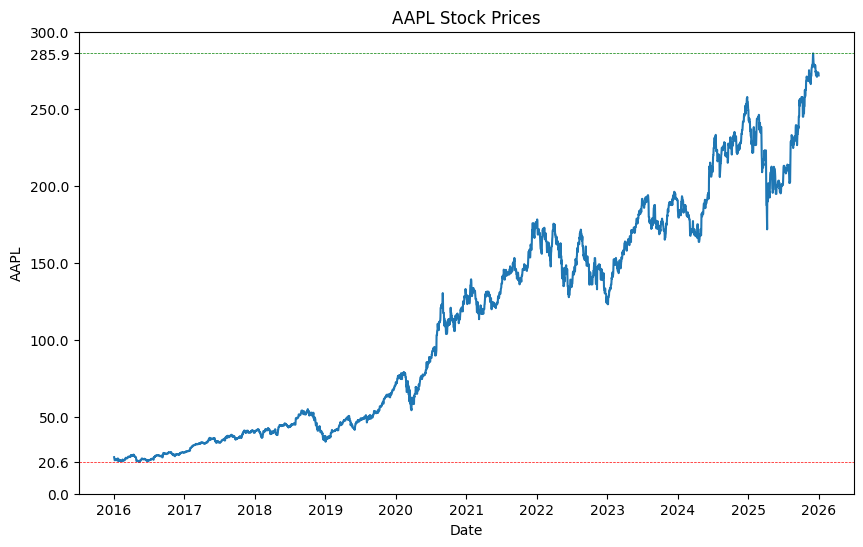

In [4]:
asset = 'AAPL'

plt.figure(figsize=(10,6))
sns.lineplot(x='Date',y= asset,data=stock_prices)

min_val = stock_prices[asset].min()
max_val = stock_prices[asset].max()

plt.axhline(min_val,color='red',linestyle='--',linewidth='0.5')
plt.axhline(max_val,color='green',linestyle='--',linewidth='0.5')
plt.title(f"{asset} Stock Prices")
yticks = list(plt.yticks()[0])
yticks.extend([min_val,max_val])
plt.yticks(sorted(yticks))


plt.show()

# **Obliczanie stóp zwrotu aktywów**

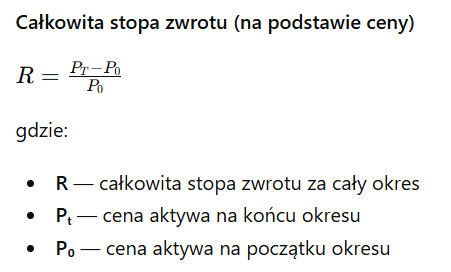

Na tym etapie obliczono dzienne stopy zwrotu aktywów na podstawie danych historycznych cen.

Stopy zwrotu stanowią podstawę do dalszych obliczeń:

*   oczekiwanej stopy zwrotu portfela
*   ryzyka (zmienności)

*   macierzy kowariancji


In [5]:
returns = stock_prices_drop_date.pct_change().dropna()
returns

Ticker,AAPL,AMZN,BTC-USD,GLD,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,XOM
1,-0.025059,-0.005024,-0.002611,0.002819,0.002752,0.001729,0.003538,0.004989,0.004562,0.016064,0.000090,0.008520
2,-0.019569,-0.001799,-0.006609,0.014441,-0.002889,-0.014436,-0.005406,0.002336,-0.018165,-0.041350,-0.019648,-0.008320
3,-0.042205,-0.039058,0.067450,0.014140,-0.024139,-0.040439,-0.016541,-0.049043,-0.034783,-0.039645,-0.015477,-0.016006
4,0.005288,-0.001464,-0.010519,-0.004428,-0.013617,-0.022399,-0.002643,-0.006025,0.003067,-0.021466,-0.021563,-0.020202
5,0.000000,0.000000,-0.012398,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
3645,0.000000,0.000000,0.005736,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3646,0.000000,0.000000,0.000384,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3647,0.001317,-0.001935,-0.007943,-0.043528,0.000159,-0.012686,0.004151,-0.006935,-0.001251,-0.012124,-0.032724,0.011922
3648,-0.002484,0.001982,0.014827,0.000728,0.000925,-0.001019,-0.001283,0.011022,0.000780,-0.003613,-0.011335,0.003816


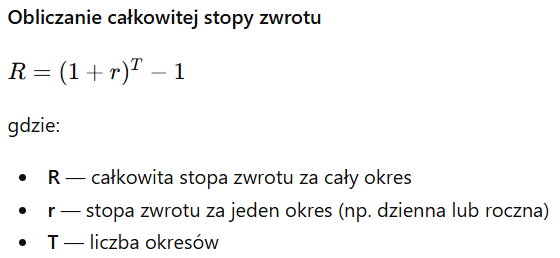

Na tym etapie obliczono łączną stopę zwrotu każdego aktywa za cały okres z wykorzystaniem procentu składanego.

In [6]:
total_return = ((1 + returns).prod() - 1).reset_index().rename(columns={0:'Total_Return'})
total_return

,Ticker,Total_Return
0,AAPL,10.445218
1,AMZN,6.247210
2,BTC-USD,201.056444
3,GLD,2.851783
4,GOOGL,7.305197
5,JPM,5.593644
6,KO,1.257732
7,META,5.502650
8,MSFT,9.078890
9,NVDA,235.199168


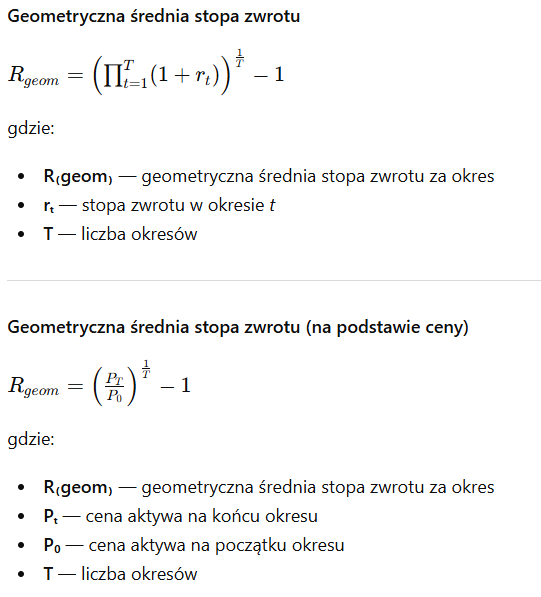

Na tym etapie obliczono średnią stopę zwrotu aktywów z uwzględnieniem procentu składanego.

Średnia geometryczna uwzględnia efekt procentu składanego i pokazuje rzeczywistą średnią stopę zwrotu z inwestycji.

Geometryczna stopa zwrotu daje bardziej dokładną ocenę rzeczywistej rentowności inwestycji w porównaniu ze średnią arytmetyczną.

In [7]:
expected_return = (((1 + returns).prod(axis=0))**(1/len(returns))-1).reset_index().rename(columns={0:'Daily_Expected_Return'})
expected_return['Weekly_Expected_Return'] = (1 + expected_return['Daily_Expected_Return'])**7 - 1
expected_return['Monthly_Expected_Return'] = (1 + expected_return['Daily_Expected_Return'])**30 - 1
expected_return['Annual_Expected_Return'] = (1 + expected_return['Daily_Expected_Return'])**365 - 1
expected_return

,Ticker,Daily_Expected_Return,Weekly_Expected_Return,Monthly_Expected_Return,Annual_Expected_Return
0,AAPL,0.000668,0.004687,0.020242,0.276120
1,AMZN,0.000543,0.003807,0.016417,0.219104
2,BTC-USD,0.001456,0.010236,0.044610,0.700632
3,GLD,0.000370,0.002590,0.011149,0.144412
4,GOOGL,0.000580,0.004069,0.017556,0.235834
5,JPM,0.000517,0.003625,0.015627,0.207633
6,KO,0.000223,0.001563,0.006718,0.084868
7,META,0.000513,0.003598,0.015511,0.205956
8,MSFT,0.000633,0.004442,0.019177,0.259995
9,NVDA,0.001499,0.010538,0.045952,0.727400


Na etapie weryfikacji średnie dzienne stopy zwrotu zostały przeliczone na roczne, a następnie roczne — na łączne za okres 10 lat. Wyniki były zgodne.

In [8]:
proverka_daily_to_annual = (1 + expected_return['Daily_Expected_Return'])**365 - 1
proverka_daily_to_annual = proverka_daily_to_annual.reset_index().rename(columns={'Daily_Expected_Return':'Annual_Return'}).drop(columns='index')

proverka_annual_to_10_years = (1 + expected_return['Annual_Expected_Return'])**10 - 1
proverka_annual_to_10_years = proverka_annual_to_10_years.reset_index().rename(columns={'Annual_Expected_Return':'Total_Return'}).drop(columns='index')

result_proverka = pd.concat([proverka_daily_to_annual, proverka_annual_to_10_years],axis=1)
result_proverka

,Annual_Return,Total_Return
0,0.276120,10.452866
1,0.219104,6.251144
2,0.700632,201.350609
3,0.144412,2.853207
4,0.235834,7.310016
5,0.207633,5.597053
6,0.084868,1.258236
7,0.205956,5.505987
8,0.259995,9.085274
9,0.727400,235.553160


# **Obliczanie ryzyka aktywów**

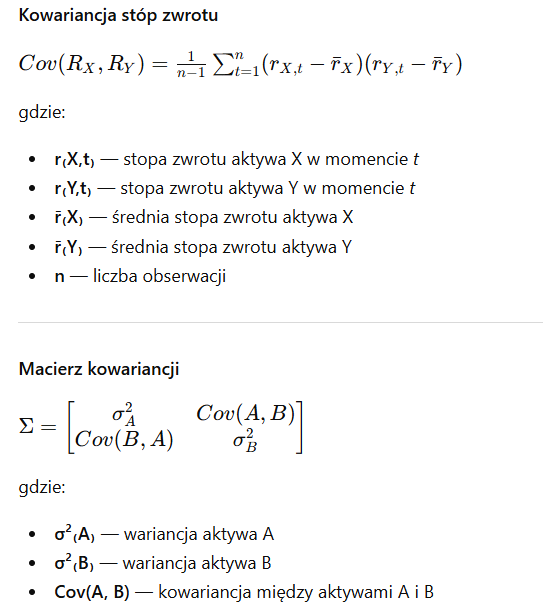

Kowariancja pokazuje kierunek ruchu aktywów:

*   (> 0) → aktywa poruszają się razem
*   (< 0) → poruszają się w przeciwnych kierunkach

*   (≈ 0) → brak zależności między nimi




Macierz pokazuje:

*   ryzyko każdego aktywa (na przekątnej)
*   zależności między aktywami (poza przekątną)



In [9]:
cov_mat = returns.cov()
cov_mat

Ticker,AAPL,AMZN,BTC-USD,GLD,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,XOM
Ticker,,,,,,,,,,,,
AAPL,0.000231,0.000150,0.000092,0.000004,0.000140,0.000091,0.000048,0.000160,0.000144,0.000213,0.000208,0.000067
AMZN,0.000150,0.000294,0.000103,0.000005,0.000165,0.000076,0.000028,0.000210,0.000160,0.000242,0.000218,0.000045
BTC-USD,0.000092,0.000103,0.001236,0.000026,0.000097,0.000071,0.000020,0.000107,0.000098,0.000174,0.000185,0.000056
GLD,0.000004,0.000005,0.000026,0.000060,0.000006,-0.000010,0.000005,0.000004,0.000003,0.000005,0.000009,0.000005
GOOGL,0.000140,0.000165,0.000097,0.000006,0.000227,0.000088,0.000041,0.000186,0.000149,0.000213,0.000183,0.000058
JPM,0.000091,0.000076,0.000071,-0.000010,0.000088,0.000208,0.000056,0.000092,0.000088,0.000126,0.000124,0.000112
KO,0.000048,0.000028,0.000020,0.000005,0.000041,0.000056,0.000089,0.000033,0.000047,0.000036,0.000037,0.000050
META,0.000160,0.000210,0.000107,0.000004,0.000186,0.000092,0.000033,0.000406,0.000169,0.000259,0.000210,0.000053
MSFT,0.000144,0.000160,0.000098,0.000003,0.000149,0.000088,0.000047,0.000169,0.000196,0.000226,0.000180,0.000054


Przeprowadzamy analizę ryzyka aktywów. Obliczono wariancję (rozproszenie stóp zwrotu) oraz odchylenie standardowe (zmienność dziennych stóp zwrotu).

In [10]:
val_vol_returns = pd.DataFrame({'Daily_Variance_Returns':returns.var(),'Daily_Volatility_Returns':returns.std()})
val_vol_returns = val_vol_returns.reset_index()
val_vol_returns

,Ticker,Daily_Variance_Returns,Daily_Volatility_Returns
0,AAPL,0.000231,0.015195
1,AMZN,0.000294,0.017152
2,BTC-USD,0.001236,0.035158
3,GLD,0.000060,0.007742
4,GOOGL,0.000227,0.015079
5,JPM,0.000208,0.014423
6,KO,0.000089,0.009443
7,META,0.000406,0.020139
8,MSFT,0.000196,0.013995
9,NVDA,0.000682,0.026111


# **Obliczanie ryzyka, stopy zwrotu oraz współczynnika Sharpe’a dla portfela równoważonego**

Na tym etapie obliczono wagi aktywów dla portfela równoważonego. Każdemu aktywu przypisywana jest taka sama waga:



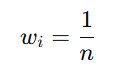

W ten sposób otrzymano bazowy zestaw wag, w którym kapitał jest równomiernie rozłożony między wszystkie aktywa.

In [11]:
n = len(total_return['Total_Return'])
weights = np.ones(n) / n
print(weights)

[0.08333333 0.08333333 0.08333333 0.08333333 0.08333333 0.08333333
 0.08333333 0.08333333 0.08333333 0.08333333 0.08333333 0.08333333]


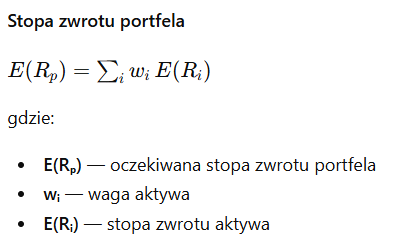

**Stopa zwrotu portfela** jest określana jako ważona suma stóp zwrotu wszystkich aktywów wchodzących w jego skład. Stopa zwrotu portfela zależy nie tylko od poszczególnych aktywów, ale także od ich wag.

Do analizy portfela stopa zwrotu obliczona na podstawie dziennej jest przeliczana na **roczną z uwzględnieniem procentu składanego.**

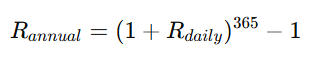

In [12]:
portfolio_return = np.dot(weights, expected_return['Daily_Expected_Return'])
print(f"Daily Equal Weight Portfolio Return = {portfolio_return:.4f}")

annual_portfolio_return =(1+portfolio_return)**365 - 1
print(f"Annual Equal Weight Portfolio Return = {annual_portfolio_return:.4f}")

Daily Equal Weight Portfolio Return = 0.0007
Annual Equal Weight Portfolio Return = 0.2823


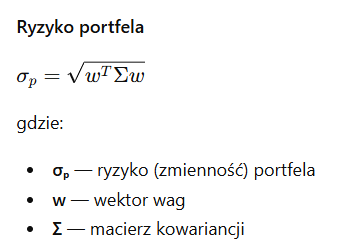

**Ryzyko (zmienność) portfela** oblicza się z wykorzystaniem **macierzy kowariancji aktywów oraz ich wag**. Ryzyko portfela zależy nie tylko od poszczególnych aktywów, ale także od ich wzajemnej korelacji.

**Dywersyfikacja** pozwala na obniżenie ryzyka portfela poprzez łączenie aktywów o różnej dynamice stóp zwrotu.

Dla poprawnej analizy portfela ryzyko obliczone na podstawie dziennej jest przeliczane na **wartość roczną**.

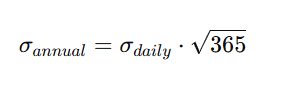

In [13]:
portfolio_risk = np.sqrt(np.dot(weights.T,np.dot(cov_mat,weights)))
print(f"Daily Equal Weight Portfolio Risk = {portfolio_risk:.4f}")
annual_portfolio_risk = portfolio_risk*np.sqrt(365)
print(f"Annual Equal Weight Portfolio Risk = {annual_portfolio_risk:.4f}")

Daily Equal Weight Portfolio Risk = 0.0113
Annual Equal Weight Portfolio Risk = 0.2159


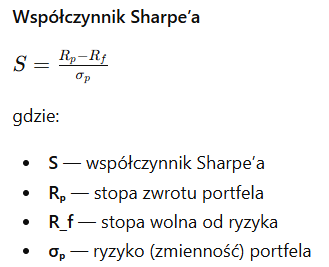

**Współczynnik Sharpe’a (Sharpe Ratio)** służy do oceny efektywności portfela inwestycyjnego z uwzględnieniem ryzyka. Pokazuje, ile dodatkowej stopy zwrotu inwestor uzyskuje na każdą jednostkę ryzyka. Różnica (Rₚ − R_f) wskazuje, o ile portfel przewyższa aktywo wolne od ryzyka.

Sharpe Ratio < 1 — słaby portfel
Sharpe Ratio 1–2 — dobry portfel
Sharpe Ratio > 2 — bardzo dobry portfel

**Stopa wolna od ryzyka (Risk-Free Rate)** to stopa zwrotu aktywa, które uznaje się za praktycznie pozbawione ryzyka. Jest wykorzystywana jako punkt odniesienia do oceny efektywności portfela inwestycyjnego.

W praktyce nie istnieją całkowicie bezpieczne aktywa, jednak stosuje się instrumenty o najwyższej wiarygodności. Jako stopę wolną od ryzyka najczęściej przyjmuje się **obligacje skarbowe (T-Bills)** o rentowności na poziomie **2%–3% rocznie**

In [14]:
rf = 0.02
sharpe_ratio = (annual_portfolio_return - rf)/annual_portfolio_risk
print(f"Sharpe Ratio Equal Weight Portfolio = {sharpe_ratio:.4f}")

Sharpe Ratio Equal Weight Portfolio = 1.2152


**Portfel równoważony**

Na tym etapie zbudowano portfel równoważony, w którym każdemu aktywu przypisana jest taka sama waga. **Portfel równoważony stanowi punkt wyjścia do analizy**, **jednak nie jest optymalny** — aby osiągnąć najlepsze wyniki, konieczne jest zmienianie wag aktywów i poszukiwanie najbardziej efektywnych kombinacji.

Zmieniając wagi aktywów, inwestor może kontrolować oczekiwaną stopę zwrotu portfela i dostosowywać go do swoich celów.

In [15]:
print(f"Annual Equal Weight Portfolio Return = {annual_portfolio_return:.4f}")
print(f"Annual Equal Weight Portfolio Risk = {annual_portfolio_risk:.4f}")
print(f"Sharpe Ratio Equal Weight Portfolio = {sharpe_ratio:.4f}")

weights_ticker_equal_weight = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': weights,
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_equal_weight


Annual Equal Weight Portfolio Return = 0.2823
Annual Equal Weight Portfolio Risk = 0.2159
Sharpe Ratio Equal Weight Portfolio = 1.2152


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.083333,0.000668,0.015195,0.276120
1,AMZN,0.083333,0.000543,0.017152,0.219104
2,BTC-USD,0.083333,0.001456,0.035158,0.700632
3,GLD,0.083333,0.000370,0.007742,0.144412
4,GOOGL,0.083333,0.000580,0.015079,0.235834
5,JPM,0.083333,0.000517,0.014423,0.207633
6,KO,0.083333,0.000223,0.009443,0.084868
7,META,0.083333,0.000513,0.020139,0.205956
8,MSFT,0.083333,0.000633,0.013995,0.259995
9,NVDA,0.083333,0.001499,0.026111,0.727400


# **Generowanie losowych portfeli**

W tym bloku kodu wykonywana jest generacja losowych portfeli z uwzględnieniem заданych ograniczeń (min_w, max_w) dotyczących wag aktywów. Zapewnia to dywersyfikację i eliminuje nadmierną koncentrację kapitału.

Obliczane są **dzienne ryzyko i stopa zwrotu portfeli**, po czym są one przeliczane na wartości roczne. Zapisywane są również **roczny współczynnik Sharpe’a oraz wagi portfeli**.

In [16]:
num_portfolios = 1000000

results = []

min_w = 0.02
max_w = 0.25
while len(results) < num_portfolios:
  weight = np.random.random(n)
  weight /= np.sum(weight)
  if np.any(weight < min_w) or np.any(weight > max_w):
    continue

  ret = np.dot(weight, expected_return['Daily_Expected_Return'])
  annual_ret = (1 + ret)**365 - 1
  risk = np.sqrt(np.dot(weight.T, np.dot(cov_mat, weight)))
  annual_risk = risk * np.sqrt(365)
  sharpe = (annual_ret - rf)/annual_risk
  results.append((annual_ret, annual_risk, sharpe, weight))

In [17]:
df_results = pd.DataFrame(results, columns=['Return', 'Risk', 'Sharpe', 'Weights'])
df_results["Return"] = df_results["Return"].round(4)
df_results["Risk"] = df_results["Risk"].round(4)
df_results["Sharpe"] = df_results["Sharpe"].round(4)
df_results["Weights"] = df_results["Weights"].round(2)

df_results['Risk'].count()
df_results

,Return,Risk,Sharpe,Weights
0,0.2831,0.2126,1.2377,"[0.05209603769967575, 0.03258774036529447, 0.0..."
1,0.2484,0.2042,1.1181,"[0.13363659610362014, 0.14859755576714823, 0.0..."
2,0.2832,0.2036,1.2926,"[0.0969297946074998, 0.04334516661777296, 0.16..."
3,0.2611,0.1992,1.2103,"[0.11603326453139641, 0.11475487092465007, 0.0..."
4,0.2883,0.2243,1.1961,"[0.11594100656270546, 0.0731109238437153, 0.04..."
...,...,...,...,...
999995,0.2962,0.2221,1.2436,"[0.0482294745646958, 0.049260270343797555, 0.1..."
999996,0.3032,0.2216,1.2777,"[0.06874418977162607, 0.047704685715337015, 0...."
999997,0.2417,0.1998,1.1096,"[0.04237423429531034, 0.040346153182609076, 0...."
999998,0.2622,0.2101,1.1530,"[0.12522020973345466, 0.08177941485492299, 0.0..."


Po wygenerowaniu losowych portfeli przeprowadzono statystykę opisową (max–min) kluczowych wskaźników: **stopy zwrotu (Return), ryzyka (Risk) oraz współczynnika Sharpe’a.**

In [18]:
df_results.describe()

,Return,Risk,Sharpe
count,1000000.000000,1000000.000000,1000000.000000
mean,0.282603,0.219739,1.194164
std,0.025902,0.014910,0.071752
min,0.184700,0.152100,0.901000
25%,0.264800,0.209600,1.146400
50%,0.282200,0.219400,1.196900
75%,0.299800,0.229500,1.244600
max,0.436800,0.310800,1.507300


# **Budowa granicy efektywnej (Efficient Frontier)**

W tym bloku kodu **budowana jest granica efektywna** na podstawie wcześniej wygenerowanych portfeli. **Granica efektywna** stanowi zbiór portfeli, które zapewniają **maksymalną stopę zwrotu przy danym poziomie ryzyka**.

Algorytm działa w następujący sposób:

Przechodzimy przez portfele w kolejności rosnącego ryzyka. Dla każdego portfela sprawdzamy, czy jego stopa zwrotu jest wyższa niż wszystkich poprzednich. Jeśli tak — dodajemy go do granicy efektywnej.

W ten sposób pozostają jedynie te portfele, które zapewniają maksymalną stopę zwrotu przy danym poziomie ryzyka.

In [19]:
df_results_sort_risk  =  df_results.sort_values('Risk')
frontier = []
max_return = -np.inf

for _, row in df_results_sort_risk.iterrows():
    if row['Return'] > max_return:
        frontier.append(row)
        max_return = row['Return']

frontier = pd.DataFrame(frontier)
frontier

,Return,Risk,Sharpe,Weights
856123,0.1852,0.1521,1.0862,"[0.04682556571177429, 0.027872996760142283, 0...."
876420,0.1965,0.1534,1.1503,"[0.06786356052901109, 0.0519157308454378, 0.03..."
335572,0.2108,0.1582,1.2054,"[0.0512761099396765, 0.021614636208931965, 0.0..."
339173,0.2173,0.1600,1.2332,"[0.08351516575461689, 0.024522831228980593, 0...."
832913,0.2220,0.1615,1.2506,"[0.02726432250832386, 0.06532981091376323, 0.0..."
...,...,...,...,...
102413,0.4133,0.2774,1.4179,"[0.0914344398327648, 0.05050240884186438, 0.21..."
353570,0.4155,0.2811,1.4071,"[0.06261834519577664, 0.07083390503540951, 0.2..."
439016,0.4194,0.2843,1.4048,"[0.05250360856170426, 0.0804010329612709, 0.21..."
509034,0.4240,0.2958,1.3657,"[0.15140634901008201, 0.033419489845765704, 0...."


# **Portfel minimalnego ryzyka**

W tym bloku kodu wyszukiwany jest portfel o najniższym poziomie ryzyka spośród wszystkich wygenerowanych kombinacji. W ten sposób wybierany jest najbardziej **konserwatywny portfel**.

Portfel ten charakteryzuje się:

*   minimalną zmiennością
*   względnie stabilną stopą zwrotu

*   umiarkowaną wartością współczynnika Sharpe’a





In [20]:
min_risk_portfolio = df_results.loc[df_results['Risk'].idxmin()]
print(min_risk_portfolio.drop('Weights').to_string())

weights_ticker_min_risk = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': min_risk_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_min_risk


Return    0.1852
Risk      0.1521
Sharpe    1.0862


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.046826,0.000668,0.015195,0.276120
1,AMZN,0.027873,0.000543,0.017152,0.219104
2,BTC-USD,0.030409,0.001456,0.035158,0.700632
3,GLD,0.214657,0.000370,0.007742,0.144412
4,GOOGL,0.065811,0.000580,0.015079,0.235834
5,JPM,0.037495,0.000517,0.014423,0.207633
6,KO,0.240933,0.000223,0.009443,0.084868
7,META,0.101362,0.000513,0.020139,0.205956
8,MSFT,0.072601,0.000633,0.013995,0.259995
9,NVDA,0.025015,0.001499,0.026111,0.727400


# **Portfel maksymalnego ryzyka**

W tym bloku kodu wyszukiwany jest portfel o najwyższym poziomie ryzyka spośród wszystkich wygenerowanych kombinacji. W ten sposób wybierany jest najbardziej **agresywny portfel**.

Portfel ten charakteryzuje się:

*   maksymalną zmiennością

*   wysoką oczekiwaną stopą zwrotu
*   potencjalnie wysokim, lecz mniej stabilnym współczynnikiem Sharpe’a



In [21]:
max_risk_portfolio = df_results.loc[df_results['Risk'].idxmax()]
print(max_risk_portfolio.drop('Weights').to_string())

weights_ticker_max_risk = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': max_risk_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_max_risk

Return    0.4368
Risk      0.3108
Sharpe    1.3409


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.038346,0.000668,0.015195,0.276120
1,AMZN,0.036219,0.000543,0.017152,0.219104
2,BTC-USD,0.154582,0.001456,0.035158,0.700632
3,GLD,0.036213,0.000370,0.007742,0.144412
4,GOOGL,0.020287,0.000580,0.015079,0.235834
5,JPM,0.044757,0.000517,0.014423,0.207633
6,KO,0.032143,0.000223,0.009443,0.084868
7,META,0.027997,0.000513,0.020139,0.205956
8,MSFT,0.100704,0.000633,0.013995,0.259995
9,NVDA,0.240800,0.001499,0.026111,0.727400


# **Portfel o maksymalnym współczynniku Sharpe’a**

W tym bloku kodu wyznaczany jest portfel o maksymalnej wartości współczynnika Sharpe’a, który uznaje się za **optymalny z punktu widzenia relacji ryzyko/dochodowość**.

Portfel ten:

*   nie jest ani najbardziej ryzykowny, ani najbardziej dochodowy
*   ale zapewnia najlepszą równowagę między nimi



In [22]:
max_sharpe_portfolio = df_results.loc[df_results['Sharpe'].idxmax()]
print(max_sharpe_portfolio.drop('Weights').to_string())

weights_ticker_max_sharpe = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': max_sharpe_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_max_sharpe

Return    0.3623
Risk      0.2271
Sharpe    1.5073


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.049446,0.000668,0.015195,0.276120
1,AMZN,0.030449,0.000543,0.017152,0.219104
2,BTC-USD,0.139238,0.001456,0.035158,0.700632
3,GLD,0.218506,0.000370,0.007742,0.144412
4,GOOGL,0.024734,0.000580,0.015079,0.235834
5,JPM,0.068866,0.000517,0.014423,0.207633
6,KO,0.074006,0.000223,0.009443,0.084868
7,META,0.020052,0.000513,0.020139,0.205956
8,MSFT,0.054727,0.000633,0.013995,0.259995
9,NVDA,0.226546,0.001499,0.026111,0.727400


# **Portfel o minimalnym współczynniku Sharpe’a**

W tym bloku kodu wyznaczany jest portfel o minimalnej wartości współczynnika Sharpe’a spośród wszystkich wygenerowanych kombinacji. Portfel ten jest najmniej **efektywny z punktu widzenia relacji ryzyko/dochodowość**.

Portfel ten:

*   charakteryzuje się niską efektywnością
*   nie rekompensuje ryzyka wystarczającą stopą zwrotu



In [23]:
min_sharpe_portfolio = df_results.loc[df_results['Sharpe'].idxmin()]
print(min_sharpe_portfolio.drop('Weights').to_string())


weights_ticker_min_sharpe = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': min_sharpe_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_min_sharpe

Return    0.2097
Risk      0.2106
Sharpe     0.901


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.059945,0.000668,0.015195,0.276120
1,AMZN,0.054436,0.000543,0.017152,0.219104
2,BTC-USD,0.030161,0.001456,0.035158,0.700632
3,GLD,0.033928,0.000370,0.007742,0.144412
4,GOOGL,0.202597,0.000580,0.015079,0.235834
5,JPM,0.035417,0.000517,0.014423,0.207633
6,KO,0.109224,0.000223,0.009443,0.084868
7,META,0.206905,0.000513,0.020139,0.205956
8,MSFT,0.047982,0.000633,0.013995,0.259995
9,NVDA,0.020340,0.001499,0.026111,0.727400


# **Portfel o maksymalnej stopie zwrotu przy zadanym poziomie ryzyka**

W tym bloku kodu wyszukiwany jest portfel, który zapewnia maksymalną stopę zwrotu przy ograniczeniu poziomu ryzyka. Jest to portfel **optymalny przy zadanym ograniczeniu ryzyka, który leży na granicy efektywnej**.

In [24]:
target_risk = 0.2

filtered_portfolios = df_results[df_results['Risk']<= target_risk]
max_return_given_risk = filtered_portfolios.loc[filtered_portfolios['Return'].idxmax()]
print(max_return_given_risk.drop('Weights').to_string())


weights_ticker_max_return_given_risk = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': max_return_given_risk['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_max_return_given_risk

Return    0.3037
Risk      0.1988
Sharpe    1.4272


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.067046,0.000668,0.015195,0.276120
1,AMZN,0.026376,0.000543,0.017152,0.219104
2,BTC-USD,0.104753,0.001456,0.035158,0.700632
3,GLD,0.167665,0.000370,0.007742,0.144412
4,GOOGL,0.022134,0.000580,0.015079,0.235834
5,JPM,0.139125,0.000517,0.014423,0.207633
6,KO,0.159667,0.000223,0.009443,0.084868
7,META,0.045932,0.000513,0.020139,0.205956
8,MSFT,0.035415,0.000633,0.013995,0.259995
9,NVDA,0.167988,0.001499,0.026111,0.727400


# **Portfel o maksymalnej stopie zwrotu**

W tym bloku kodu wyznaczany jest portfel o maksymalnej oczekiwanej stopie zwrotu spośród wszystkich wygenerowanych kombinacji. **Portfel ten zapewnia najwyższy poziom oczekiwanego zysku**.

Portfel ten:

*   ma najwyższą stopę zwrotu spośród wszystkich wariantów
*   wiąże się z wysokim poziomem ryzyka



In [25]:
max_profit_portfolio = df_results.loc[df_results['Return'].idxmax()]
print(max_profit_portfolio.drop('Weights').to_string())


weights_ticker_max_profit = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': max_profit_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_max_profit

Return    0.4368
Risk      0.3108
Sharpe    1.3409


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.038346,0.000668,0.015195,0.276120
1,AMZN,0.036219,0.000543,0.017152,0.219104
2,BTC-USD,0.154582,0.001456,0.035158,0.700632
3,GLD,0.036213,0.000370,0.007742,0.144412
4,GOOGL,0.020287,0.000580,0.015079,0.235834
5,JPM,0.044757,0.000517,0.014423,0.207633
6,KO,0.032143,0.000223,0.009443,0.084868
7,META,0.027997,0.000513,0.020139,0.205956
8,MSFT,0.100704,0.000633,0.013995,0.259995
9,NVDA,0.240800,0.001499,0.026111,0.727400


# **Portfel o minimalnej stopie zwrotu**

W tym bloku kodu wyznaczany jest portfel o minimalnej oczekiwanej stopie zwrotu spośród wszystkich wygenerowanych kombinacji. **Portfel ten jest najmniej dochodowym wariantem**.

Portfel ten:

*   ma najniższą stopę zwrotu
*   przy czym ryzyko może pozostawać na średnim poziomie



In [26]:
min_profit_portfolio = df_results.loc[df_results['Return'].idxmin()]
print(min_profit_portfolio.drop('Weights').to_string())


weights_ticker_min_profit = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Weight': min_profit_portfolio['Weights'],
    'Expected Return Daily': expected_return['Daily_Expected_Return'],
    'Volatility Return Daily': val_vol_returns['Daily_Volatility_Returns'],
    'Expected Return Annual': expected_return['Annual_Expected_Return']
  })
weights_ticker_min_profit

Return    0.1847
Risk      0.1815
Sharpe    0.9074


,Ticker,Weight,Expected Return Daily,Volatility Return Daily,Expected Return Annual
0,AAPL,0.050191,0.000668,0.015195,0.276120
1,AMZN,0.023470,0.000543,0.017152,0.219104
2,BTC-USD,0.027773,0.001456,0.035158,0.700632
3,GLD,0.065093,0.000370,0.007742,0.144412
4,GOOGL,0.059197,0.000580,0.015079,0.235834
5,JPM,0.087261,0.000517,0.014423,0.207633
6,KO,0.219119,0.000223,0.009443,0.084868
7,META,0.159880,0.000513,0.020139,0.205956
8,MSFT,0.020209,0.000633,0.013995,0.259995
9,NVDA,0.029368,0.001499,0.026111,0.727400


# **Linia rynku kapitałowego (CML)**

**Capital Market Line (CML)** to linia, która przedstawia optymalną relację między ryzykiem a stopą zwrotu dla portfeli obejmujących aktywo wolne od ryzyka oraz portfel rynkowy (portfel o maksymalnym współczynniku Sharpe’a).

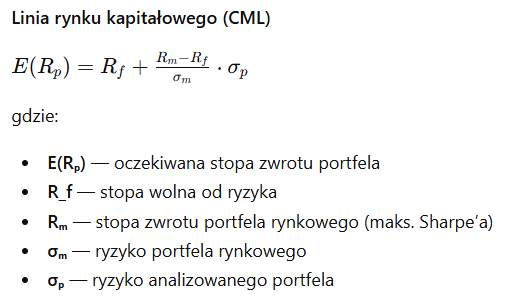

**Linia CML** przedstawia wszystkie możliwe optymalne portfele, które można uzyskać poprzez łączenie:

*   aktywa wolnego od ryzyka (np. obligacje)
*   portfela rynkowego (maks. Sharpe’a)



In [27]:
risk_range = np.linspace(0, 0.5, 100)

cml = rf + (max_sharpe_portfolio['Return'] - rf) / max_sharpe_portfolio['Risk'] * risk_range


# **Budowa wykresu Efficient Frontier — alokacja portfela**

Na przedstawionym wykresie pokazano zależność między ryzykiem a stopą zwrotu różnych portfeli, a także kluczowe punkty odniesienia dla podejmowania decyzji inwestycyjnych.

**Każdy punkt** reprezentuje osobny losowo wygenerowany portfel. **Kolor punktów** odzwierciedla **współczynnik Sharpe’a**. Im wyżej i bardziej na lewo znajduje się punkt — **tym bardziej efektywny jest portfel**.

**Efficient Frontier (czerwona linia)** pokazuje najlepsze portfele dla każdego poziomu ryzyka. Tworzy ona górną granicę chmury punktów. Powyżej niej nie da się osiągnąć lepszych wyników.

Interpretacja:

*   większość losowych portfeli znajduje się poniżej Efficient Frontier — portfele te nie są optymalne

*   tylko niewielka część to portfele optymalne, które leżą na Efficient Frontier
*   portfel o maksymalnym współczynniku Sharpe’a wyznacza najlepszą strategię

Inwestor powinien dążyć do portfeli znajdujących się na **Efficient Frontier** i, idealnie, wykorzystywać kombinacje wzdłuż **Capital Market Line**, aby osiągnąć maksymalną stopę zwrotu na jednostkę ryzyka.







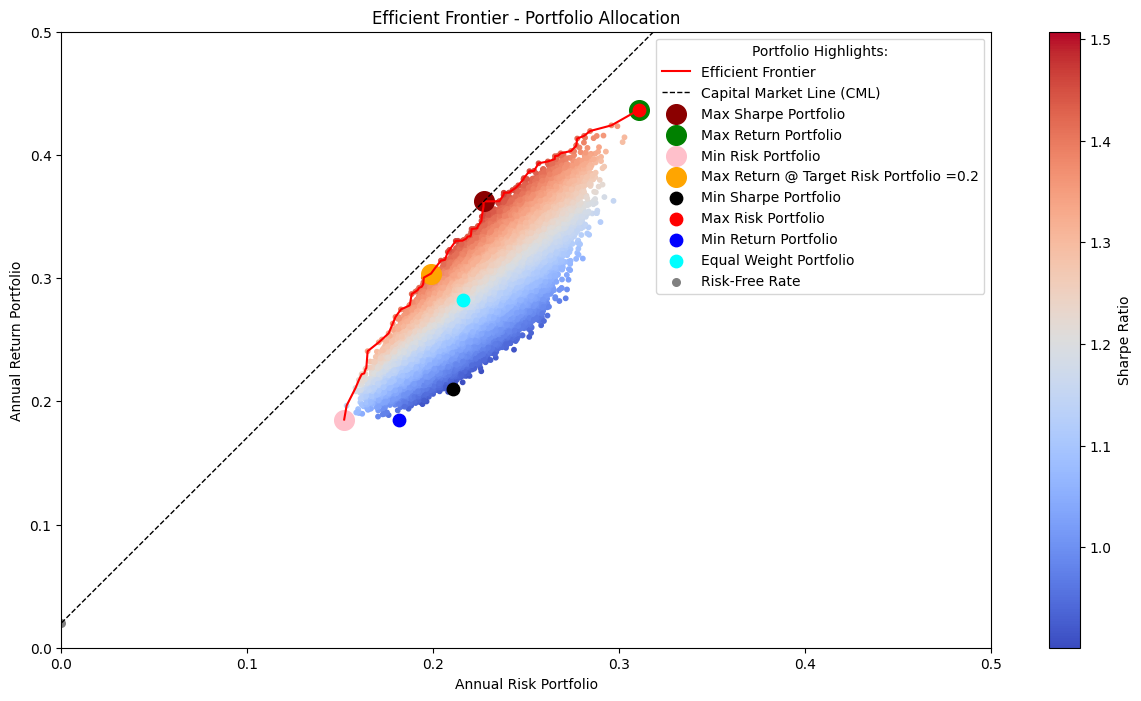

In [28]:
plt.figure(figsize=(15, 8))

sc = plt.scatter(df_results['Risk'], df_results['Return'],c = df_results['Sharpe'],cmap = 'coolwarm' ,s=10)
plt.colorbar(sc, label='Sharpe Ratio')


plt.plot(
    frontier['Risk'],
    frontier['Return'],
    color='red',
    linewidth=1.5,
    label='Efficient Frontier'
)

plt.plot(risk_range, cml, color='black', linestyle='--', linewidth=1, label='Capital Market Line (CML)')


plt.scatter(
    max_sharpe_portfolio['Risk'], max_sharpe_portfolio['Return'],
    marker='o', s=200, label='Max Sharpe Portfolio',color='darkred'
)

plt.scatter(
    max_profit_portfolio['Risk'],
    max_profit_portfolio['Return'],
    marker='o',
    s=200,
    label='Max Return Portfolio',
    color='green'
)

plt.scatter(
    min_risk_portfolio['Risk'], min_risk_portfolio['Return'],
    marker='o', s=200, label='Min Risk Portfolio', color='pink'
)

plt.scatter(
    max_return_given_risk['Risk'], max_return_given_risk['Return'],
    marker='o', s=200, label=f"Max Return @ Target Risk Portfolio ={target_risk}",color='orange'
)

plt.scatter(
    min_sharpe_portfolio['Risk'], min_sharpe_portfolio['Return'],
    marker='o', s=80, label='Min Sharpe Portfolio',color='black'
)

plt.scatter(
    max_risk_portfolio['Risk'],
    max_risk_portfolio['Return'],
    marker='o',
    s=80,
    label='Max Risk Portfolio',
    color='red'
)

plt.scatter(
    min_profit_portfolio['Risk'],
    min_profit_portfolio['Return'],
    marker='o',
    s=80,
    label='Min Return Portfolio',
    color='blue'
)

plt.scatter (
    annual_portfolio_risk,
    annual_portfolio_return,
    marker='o',
    s=80,
    label='Equal Weight Portfolio',
    color='cyan'
)

plt.scatter(0,rf,color='gray',s=30,label='Risk-Free Rate')


plt.title('Efficient Frontier - Portfolio Allocation')
plt.xlabel('Annual Risk Portfolio')
plt.ylabel('Annual Return Portfolio')
plt.ylim(0,0.5)
plt.xlim(0,0.5)


plt.legend(title='Portfolio Highlights:')
plt.show()

# **Tabela podsumowująca portfele**

W tej tabeli przedstawiono wagi aktywów dla różnych typów portfeli, a także ich odpowiednie charakterystyki stopy zwrotu i ryzyka. Tabela podsumowująca pokazuje, że struktura portfela bezpośrednio zależy od celu inwestycyjnego:

*   maksymalizacja stopy zwrotu
*   minimalizacja ryzyka

*   optymalizacja pod względem współczynnika Sharpe’a


In [33]:
print('======== Max Sharpe ==========')
print(max_sharpe_portfolio.drop('Weights').to_string())


print('======== Min Sharpe ===========')
print(min_sharpe_portfolio.drop('Weights').to_string())



print('========  Max Profit===========')
print(max_profit_portfolio.drop('Weights').to_string())


print('========  Min Profit============')
print(min_profit_portfolio.drop('Weights').to_string())


print('========  Max Risk ============')
print(max_risk_portfolio.drop('Weights').to_string())


print('==========  Min Risk  ===========')
print(min_risk_portfolio.drop('Weights').to_string())


print(f"Target Risk  = {target_risk}")
print(max_return_given_risk.drop('Weights').to_string())



portfolio_allocation = pd.DataFrame({
    'Ticker': expected_return['Ticker'],
    'Max Sharpe': weights_ticker_max_sharpe['Weight'],
    'Min Sharpe': weights_ticker_min_sharpe['Weight'],
    'Max Return': weights_ticker_max_profit['Weight'],
    'Min Return': weights_ticker_min_profit['Weight'],
    'Max Risk': weights_ticker_max_risk['Weight'],
    'Min Risk': weights_ticker_min_risk['Weight'],
    'Max Return Given Risk': weights_ticker_max_return_given_risk['Weight'],
    'Annual Return': expected_return['Annual_Expected_Return'],
    'Daily Volatility': val_vol_returns['Daily_Volatility_Returns']


})
portfolio_allocation

======== Max Sharpe ==========
Return    0.3623
Risk      0.2271
Sharpe    1.5073
======== Min Sharpe ===========
Return    0.2097
Risk      0.2106
Sharpe     0.901
========  Max Profit===========
Return    0.4368
Risk      0.3108
Sharpe    1.3409
========  Min Profit============
Return    0.1847
Risk      0.1815
Sharpe    0.9074
========  Max Risk ============
Return    0.4368
Risk      0.3108
Sharpe    1.3409
==========  Min Risk  ===========
Return    0.1852
Risk      0.1521
Sharpe    1.0862
Target Risk  = 0.2
Return    0.3037
Risk      0.1988
Sharpe    1.4272


,Ticker,Max Sharpe,Min Sharpe,Max Return,Min Return,Max Risk,Min Risk,Max Return Given Risk,Annual Return,Daily Volatility
0,AAPL,0.049446,0.059945,0.038346,0.050191,0.038346,0.046826,0.067046,0.276120,0.015195
1,AMZN,0.030449,0.054436,0.036219,0.023470,0.036219,0.027873,0.026376,0.219104,0.017152
2,BTC-USD,0.139238,0.030161,0.154582,0.027773,0.154582,0.030409,0.104753,0.700632,0.035158
3,GLD,0.218506,0.033928,0.036213,0.065093,0.036213,0.214657,0.167665,0.144412,0.007742
4,GOOGL,0.024734,0.202597,0.020287,0.059197,0.020287,0.065811,0.022134,0.235834,0.015079
5,JPM,0.068866,0.035417,0.044757,0.087261,0.044757,0.037495,0.139125,0.207633,0.014423
6,KO,0.074006,0.109224,0.032143,0.219119,0.032143,0.240933,0.159667,0.084868,0.009443
7,META,0.020052,0.206905,0.027997,0.159880,0.027997,0.101362,0.045932,0.205956,0.020139
8,MSFT,0.054727,0.047982,0.100704,0.020209,0.100704,0.072601,0.035415,0.259995,0.013995
9,NVDA,0.226546,0.020340,0.240800,0.029368,0.240800,0.025015,0.167988,0.727400,0.026111


# **Analiza aktywów wchodzących w skład portfeli**

**AKTYWA O WYSOKIEJ STOPIE ZWROTU**:

**BTC-USD** ma wysoką wagę w portfelach (Max Sharpe, Max Return, Max Risk ≈ 20%) i zapewnia:

*   maksymalną stopę zwrotu
*   ale zwiększa ryzyko

**NVDA** ma wysoką wagę w portfelach (Max Sharpe, Max Return, Max Risk ≈ 20%) i jest:

*   kluczowym motorem wzrostu

**TSLA** ma podwyższoną wagę w portfelach ryzykownych i zapewnia:

*   wysoką stopę zwrotu
*   wysoką zmienność

**AKTYWA DEFENSYWNE**:

**GLD (złoto)** ma wysoką wagę w portfelach (Max Sharpe, Min Risk ≈ 20%) i pełni rolę:

*   stabilizatora

*   obniża zmienność

**KO (Coca-Cola)** ma wysoką wagę w portfelu (Min Risk ≈ 20%) i charakteryzuje się:

*   niską stopą zwrotu
*   niskim ryzykiem

**XOM** występuje w portfelach o niskim ryzyku i zrównoważonych oraz zapewnia:

*   dywersyfikację
*   stabilność

**AKTYWA ZRÓWNOWAŻONE**:

**AAPL, MSFT, GOOGL** występują niemal we wszystkich portfelach i mają umiarkowane wagi:

*   stanowią podstawę portfela

**AMZN, META** — ich wagi znacznie się różnią, wykorzystywane są jako:

*   wzmacniacze stopy zwrotu
*   ale nie zawsze są niezbędne

Efektywność portfela jest określana nie przez pojedyncze aktywa, lecz przez ich kombinację: aktywa o wysokiej stopie zwrotu zwiększają rentowność, defensywne — obniżają ryzyko, a zrównoważone zapewniają stabilność struktury.









# **Obliczanie optymalnego portfela CML**

W tej części zbudowano **portfel na Capital Market Line (CML)**, aby pokazać, że kombinacja aktywa wolnego od ryzyka oraz optymalnego portfela ryzykownego pozwala osiągnąć tę samą stopę zwrotu przy niższym poziomie ryzyka.

Jako docelową stopę zwrotu przyjęto **stopę zwrotu portfela minimalnego ryzyka**, który znajduje się na granicy efektywnej.

Obliczono udział kapitału inwestowanego w:

*   **portfel tangencyjny (Max Sharpe Portfolio)**

Pozostała część kapitału inwestowana jest w:

*   **aktywo wolne od ryzyka (risk-free asset)**

Ryzyko jest określane wyłącznie przez udział w portfelu ryzykownym (**ponieważ aktywo wolne od ryzyka ma zerową zmienność**). Końcowa stopa zwrotu stanowi ważoną kombinację:

*   portfela ryzykownego
*   aktywa wolnego od ryzyka

Uzyskany wynik pokazuje:

Portfel minimalnego ryzyka (składający się wyłącznie z aktywów ryzykownych) jest nieefektywny, jeśli dostępne jest aktywo wolne od ryzyka. Wykorzystując linię rynku kapitałowego:

*   można zachować tę samą stopę zwrotu
*   a jednocześnie obniżyć ryzyko










In [34]:
target_return_cml = min_risk_portfolio['Return']

tangenc_portfolio_weight = (target_return_cml - rf) / (max_sharpe_portfolio['Return'] - rf)
tangenc_portfolio_weight

asset_risk_free_weight = 1 - tangenc_portfolio_weight
asset_risk_free_weight

target_risk_cml = tangenc_portfolio_weight * max_sharpe_portfolio['Risk']
print(f"Risk CML = {target_risk_cml:.4f}")

return_cml = tangenc_portfolio_weight * max_sharpe_portfolio['Return'] + asset_risk_free_weight * rf
print(f"Return CML = {return_cml}")

target_cml_portfolio = pd.DataFrame({
    'Tangenc Portfolio Weight': [tangenc_portfolio_weight],
    'Risk Free Asset Weight': [asset_risk_free_weight]
})
target_cml_portfolio

Risk CML = 0.1096
Return CML = 0.1852


,Tangenc Portfolio Weight,Risk Free Asset Weight
0,0.482618,0.517382


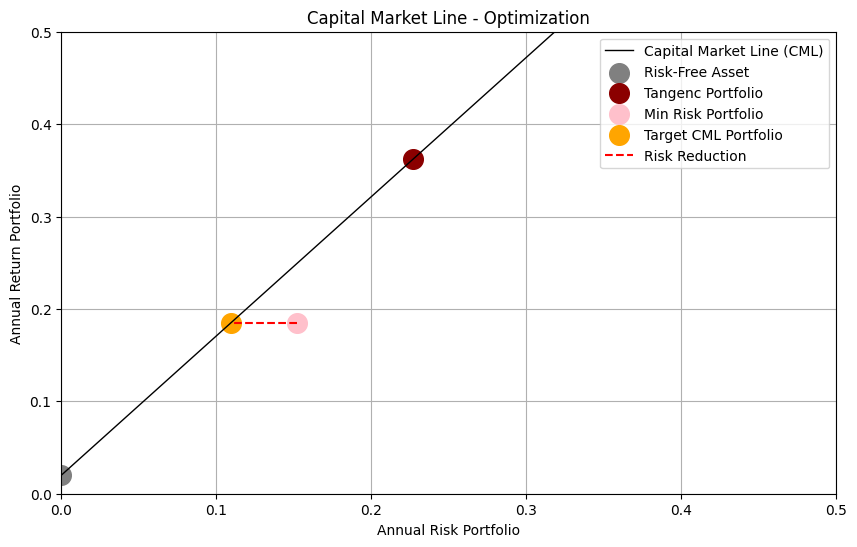

In [35]:
plt.figure(figsize=(10, 6))

plt.plot(risk_range, cml, color='black', linestyle='-', linewidth=1, label='Capital Market Line (CML)')

plt.scatter(0,rf,color='gray',s=200,label='Risk-Free Asset')

plt.scatter(
    max_sharpe_portfolio['Risk'], max_sharpe_portfolio['Return'],
    marker='o', s=200, label='Tangenc Portfolio',color='darkred'
)

plt.scatter(
    min_risk_portfolio['Risk'], min_risk_portfolio['Return'],
    marker='o', s=200, label='Min Risk Portfolio', color='pink'
)

plt.scatter(
    target_risk_cml,
    return_cml,
    marker='o',
    s=200,
    label='Target CML Portfolio',
    color='orange'
)

plt.plot(
    [min_risk_portfolio['Risk'], target_risk_cml],
    [min_risk_portfolio['Return'], return_cml],
    color='red',
    linewidth=1.5,
    linestyle='--',
    label='Risk Reduction'
)




plt.title('Capital Market Line - Optimization')
plt.xlabel('Annual Risk Portfolio')
plt.ylabel('Annual Return Portfolio')
plt.legend()
plt.ylim(0,0.5)
plt.xlim(0,0.5)
plt.grid(True)

# **Wnioski i podsumowanie**

Z projektu dowiedzieliśmy się:

Efektywne portfele znajdują się na granicy efektywnej, co oznacza, że uzyskujemy maksymalną stopę zwrotu dla każdego danego poziomu ryzyka.

Najbardziej optymalny jest portfel o maksymalnym współczynniku Sharpe’a, który ma następujące parametry:

*   Return = 0.3623
*   Risk = 0.2271

*   Sharpe = 1.5073

Portfel ten jest portfelem tangencyjnym — znajduje się zarówno na granicy efektywnej, jak i na linii rynku kapitałowego (CML), co czyni go najbardziej efektywnym spośród wszystkich 1 000 000 wygenerowanych portfeli.

Wybór portfela zależy od celów inwestora. Inwestor może korzystać z dowolnych portfeli znajdujących się na granicy efektywnej. Na przykład można wybrać defensywny portfel minimalnego ryzyka o następujących parametrach:

*   Return = 0.1852
*   Risk = 0.1521

*   Sharpe = 1.0862

Portfel ten, choć znajduje się na granicy efektywnej, nie leży na linii CML.

W takim przypadku należy go „przesunąć” na tę linię. Osiąga się to poprzez redystrybucję kapitału między portfel tangencyjny a aktywo wolne od ryzyka. Inwestując 48% kapitału w portfel tangencyjny i 52% w aktywo wolne od ryzyka, otrzymujemy portfel o następujących parametrach:

*   Return = 0.1852
*   Risk = 0.1096

*   Sharpe = 1.5073

Portfel ten znajduje się na linii rynku kapitałowego, ponieważ ma taki sam współczynnik Sharpe’a (1.5073) jak portfel tangencyjny. Jednocześnie, przy tej samej stopie zwrotu (0.1852) co portfel minimalnego ryzyka, jego ryzyko spada z 0.1521 do 0.1096.

Kombinacja aktywa wolnego od ryzyka oraz portfela o maksymalnym współczynniku Sharpe’a dominuje nad każdym portfelem na granicy efektywnej. **Efektywny inwestor zawsze znajduje się na linii CML**.








